In [107]:
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point, Polygon
import PyQt5


In [108]:
%matplotlib inline

In [109]:
import os
flds = [os.path.join(r'C:\Users\seifert\Pictures\Temp\Out\ResultTotal_5\Crops\0000', x) for x in os.listdir(r'C:\Users\seifert\Pictures\Temp\Out\ResultTotal_5\Crops\0000')]

In [110]:
file = flds[1]
#file = np.random.choice(flds)
num = int(os.path.basename(file))
file = os.path.join(file, f'poly{str(num).zfill(3)}.txt')
with open(file, 'r') as f:
    for line in f:
        parts = line.split(' ')
        pts = [float(x) for x in parts[1:-1]]


In [111]:
xs = []
ys = []

In [112]:
for i, val in enumerate(pts):
    if i % 2 == 0:
        xs.append(val)
    else:
        ys.append(val)

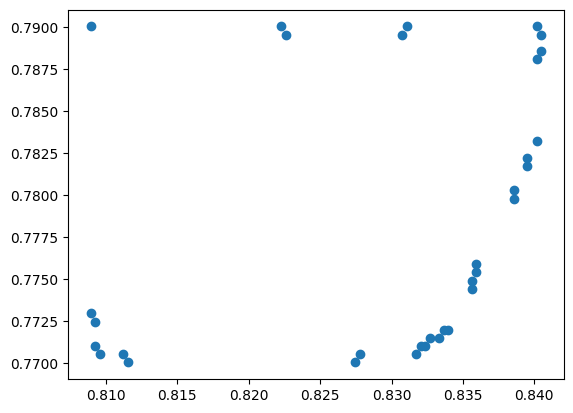

In [113]:
plt.scatter(xs, ys)
# plt.xlim(0,1)
# plt.ylim(0,1)
# plt.figaspect(1)

In [114]:
res = 100

In [115]:
pts = [(x, y) for x, y in zip(xs, ys)]

In [116]:
xmax = np.amax(xs)
xmin = np.amin(xs)
ymax = np.amax(ys)
ymin = np.amin(ys)
wmax = np.sqrt(2) * (xmax - xmin)
hmax = np.sqrt(2) * (ymax - ymin)
newdim = max(wmax, hmax)

old_mid_x = (xmax + xmin)/2
old_mid_y = (ymax + ymin)/2

plg = Polygon(pts)

In [117]:
new_mid_x = (res-1)/2
new_mid_y = (res - 1)/2
def pol_coos(x, y, theta):
    # print("X, Y", x, y)
    dx = x - new_mid_x
    dy = new_mid_y - y
    # print('DX, DY', dx, dy)
    v = np.array([dx, dy])
    rot = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    vs = np.dot(v, rot)
    # print("V: ", vs)
    # print(f'{(newdim / res)} * {vs[0]} + {old_mid_x}')

    old_x = (newdim / res) * vs[0] + old_mid_x
    old_y = (newdim / res) * vs[1] + old_mid_y

    return old_x, old_y

In [118]:
def gen_shape(poly, theta):
    mat = np.zeros((res, res))
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ox, oy = pol_coos(j, i, theta)
            # print(f'{j}, {i} --> {ox}, {oy}')
            if poly.contains(Point(ox, oy)):
                mat[i, j] = 1
                print(i, j)

    return mat

In [119]:
#%matplotlib qt5

28 15
28 16
28 17
28 18
28 19
28 20
28 21
28 22
28 23
28 24
28 25
28 26
28 27
28 28
28 29
28 30
28 31
28 32
28 33
28 34
28 35
28 36
28 37
28 38
28 39
28 40
28 41
28 42
28 43
28 44
28 64
28 65
28 66
28 67
28 68
28 69
28 70
28 71
28 72
28 73
28 74
28 75
28 76
28 77
28 78
28 79
28 80
28 81
28 82
28 83
28 84
29 15
29 16
29 17
29 18
29 19
29 20
29 21
29 22
29 23
29 24
29 25
29 26
29 27
29 28
29 29
29 30
29 31
29 32
29 33
29 34
29 35
29 36
29 37
29 38
29 39
29 40
29 41
29 42
29 43
29 44
29 45
29 46
29 47
29 48
29 49
29 50
29 51
29 52
29 53
29 54
29 55
29 56
29 57
29 58
29 59
29 60
29 61
29 62
29 63
29 64
29 65
29 66
29 67
29 68
29 69
29 70
29 71
29 72
29 73
29 74
29 75
29 76
29 77
29 78
29 79
29 80
29 81
29 82
29 83
29 84
30 15
30 16
30 17
30 18
30 19
30 20
30 21
30 22
30 23
30 24
30 25
30 26
30 27
30 28
30 29
30 30
30 31
30 32
30 33
30 34
30 35
30 36
30 37
30 38
30 39
30 40
30 41
30 42
30 43
30 44
30 45
30 46
30 47
30 48
30 49
30 50
30 51
30 52
30 53
30 54
30 55
30 56
30 57
30 58
30 59
30 6

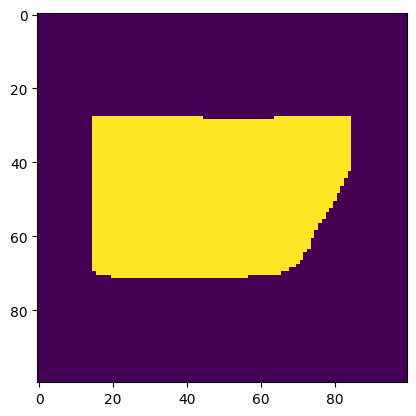

In [120]:
arr = gen_shape(plg, theta=0)
plt.imshow(arr)

In [121]:
def rect(xmin, xmax, ymin, ymax):
    arr = np.zeros((res, res))
    arr[ymin:ymax,xmin:xmax] =1
    return arr

In [122]:
mat2 = rect(30, 70, 30, 70)

In [123]:
def iou(mat1, mat2):
    i = np.sum(np.multiply(mat1, mat2))
    u = np.sum(np.maximum(mat1, mat2))
    return i / u

In [124]:
iou(arr, mat2)

0.5713264211655344

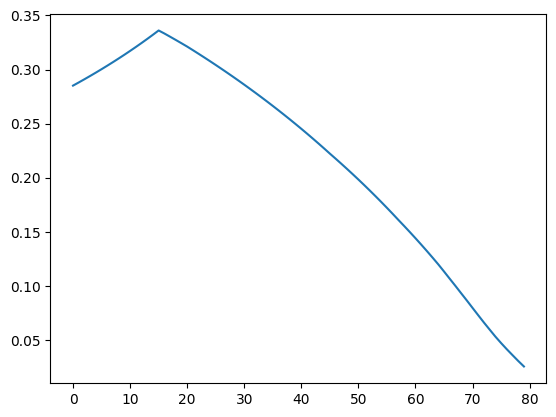

In [125]:
xmins = []
iou_xmin = []
xmax = arr.shape[1]-1
ymin = 0
ymax = arr.shape[0]-1

for i in range(int(0.8 * arr.shape[1])):
    xmins.append(i)
    arr2 = rect(i, xmax, ymin, ymax)
    iou_xmin.append(iou(arr, arr2))

plt.plot(xmins, iou_xmin)

In [126]:
xmin = xmins[np.argmax(iou_xmin)]

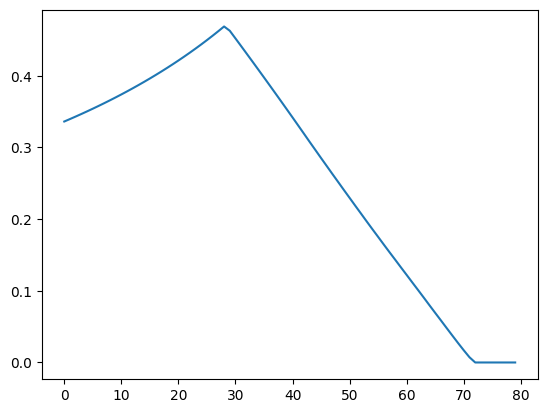

In [127]:
ymins = []
iou_ymin = []
xmax = arr.shape[1] - 1
ymax = arr.shape[0]-1

for i in range(int(0.8 * arr.shape[0])):
    ymins.append(i)
    arr2 = rect(xmin, xmax, i, ymax)
    iou_ymin.append(iou(arr, arr2))

plt.plot(ymins, iou_ymin)

In [128]:
ymin = ymins[np.argmax(iou_ymin)]

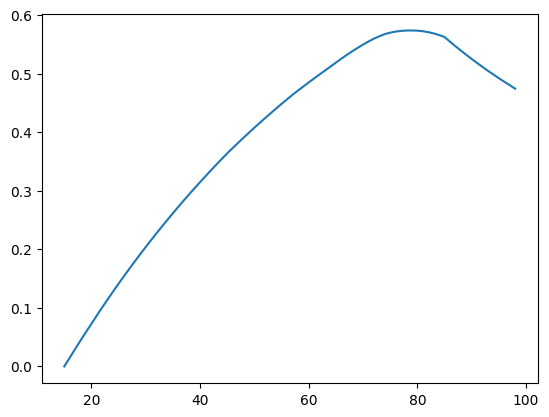

In [129]:
xmaxs = []
iou_xmax = []
ymax = arr.shape[0]-1

for i in range(xmin, arr.shape[1]-1):
    xmaxs.append(i)
    arr2 = rect(xmin, i, ymin, ymax)
    iou_xmax.append(iou(arr, arr2))

plt.plot(xmaxs, iou_xmax)

In [130]:
xmax = xmaxs[np.argmax(xmaxs)]

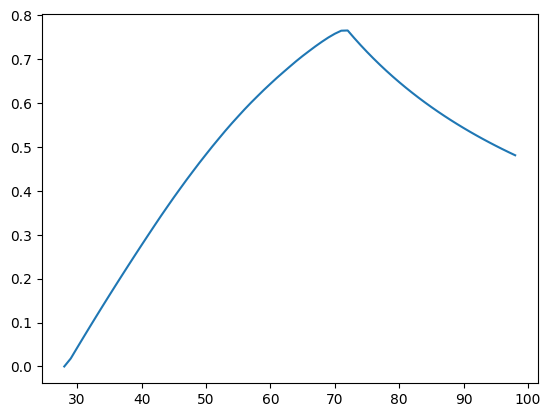

In [131]:
ymaxs = []
iou_ymax = []

for i in range(ymin, arr.shape[0]-1):
    ymaxs.append(i)
    arr2 = rect(xmin, xmax, ymin, i)
    iou_ymax.append(iou(arr, arr2))

plt.plot(ymaxs, iou_ymax)

In [132]:
ymax = ymaxs[np.argmax(iou_ymax)]

Text(0.5, 1.0, '15 -> 15')

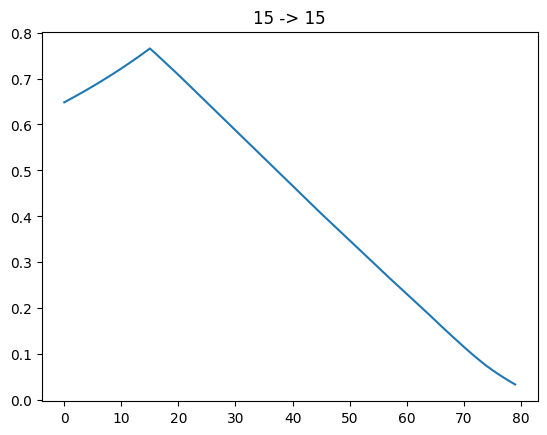

In [133]:
xmins = []
iou_xmin = []

for i in range(int(0.8 * arr.shape[1])):
    xmins.append(i)
    arr2 = rect(i, xmax, ymin, ymax)
    iou_xmin.append(iou(arr, arr2))

new_xmin = xmins[np.argmax(iou_xmin)]
plt.plot(xmins, iou_xmin)
plt.title(f'{xmin} -> {new_xmin}')